In [66]:
# importing the required packages
import czifile # to import a .czi file
from PIL import Image # to convert .czi file to a .tif file
import skimage # general package for manipulating imaging data
from pathlib import Path # for file path 
import numpy as np
import matplotlib.pyplot as plt
from microfilm.microplot import microshow # for viewing multichannel image data
from skimage.restoration import rolling_ball # for image processing
from skimage.filters import gaussian # for image processing
from skimage.feature import peak_local_max # for local max detection
import pyclesperanto_prototype as cle # package for additional vizualization


In [67]:
# importing a czi file, checking the shape of the image array and getting info about image acquisition
image = czifile.imread(Path("D:/code/Image-analysis/test-images-VLGUT1-PSD95/OE_Exp1_IHC_Exp1_HA-GPR37L1_555-VGLUT1_647-PSD95_63X_airyscan_1.8zoom_CA1_SO.czi"))
image.shape

(1, 1, 2, 1, 1, 1000, 1000, 1)

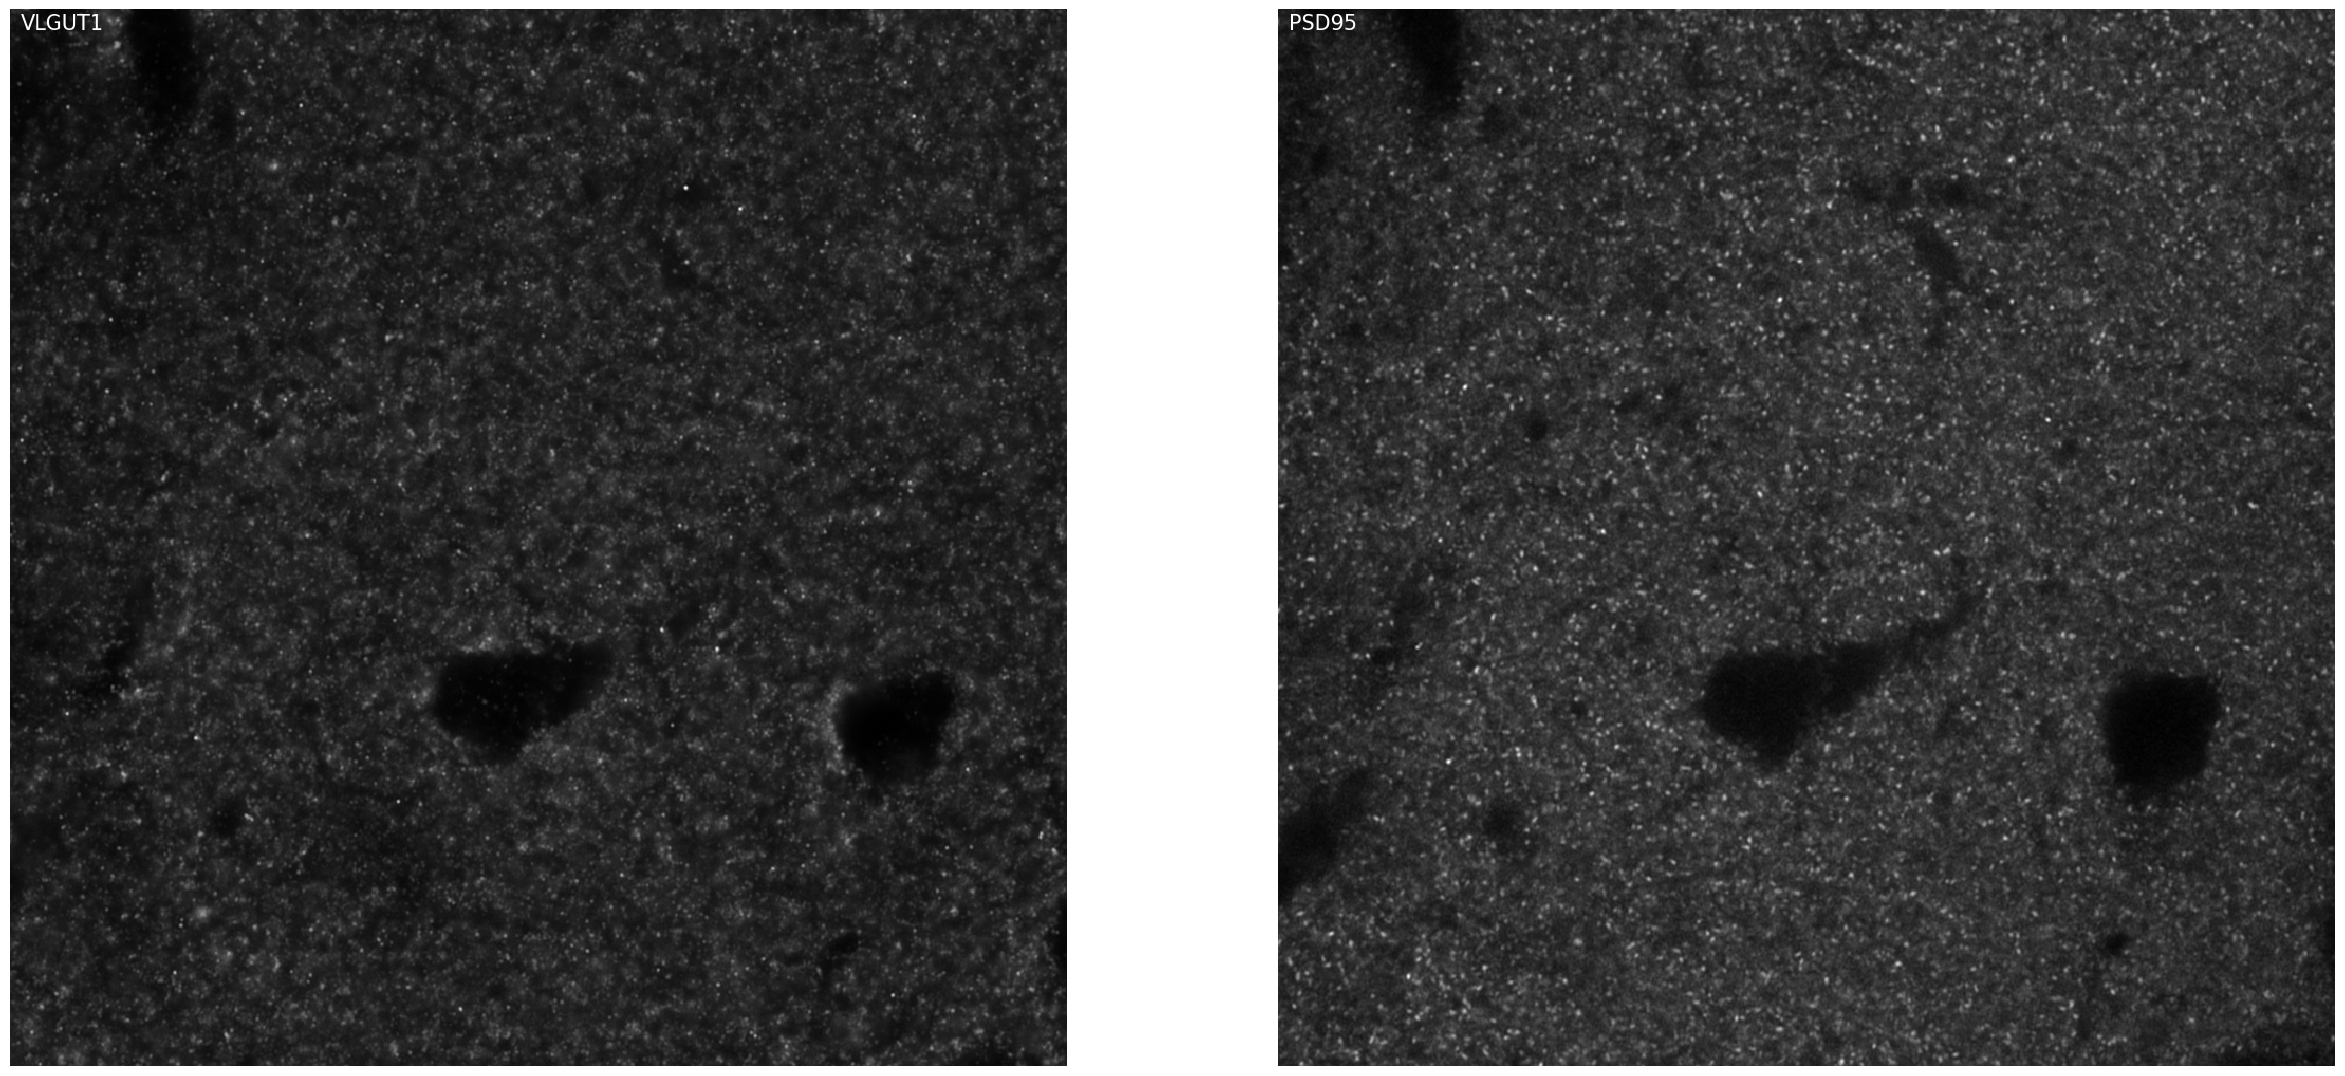

In [68]:
# getting rid of all the extra channels, splitting the channels and showing them one by one.
image_squeezed = np.squeeze(image)
image_squeezed.shape
vglut1 = image_squeezed[0,:,:]
psd95 = image_squeezed[1,:,:]

fig, axs = plt.subplots(1, 2, figsize = (30, 30))
microshow(vglut1, ax=axs[0], label_text = 'VLGUT1')
microshow(psd95, ax=axs[1], label_text = 'PSD95')


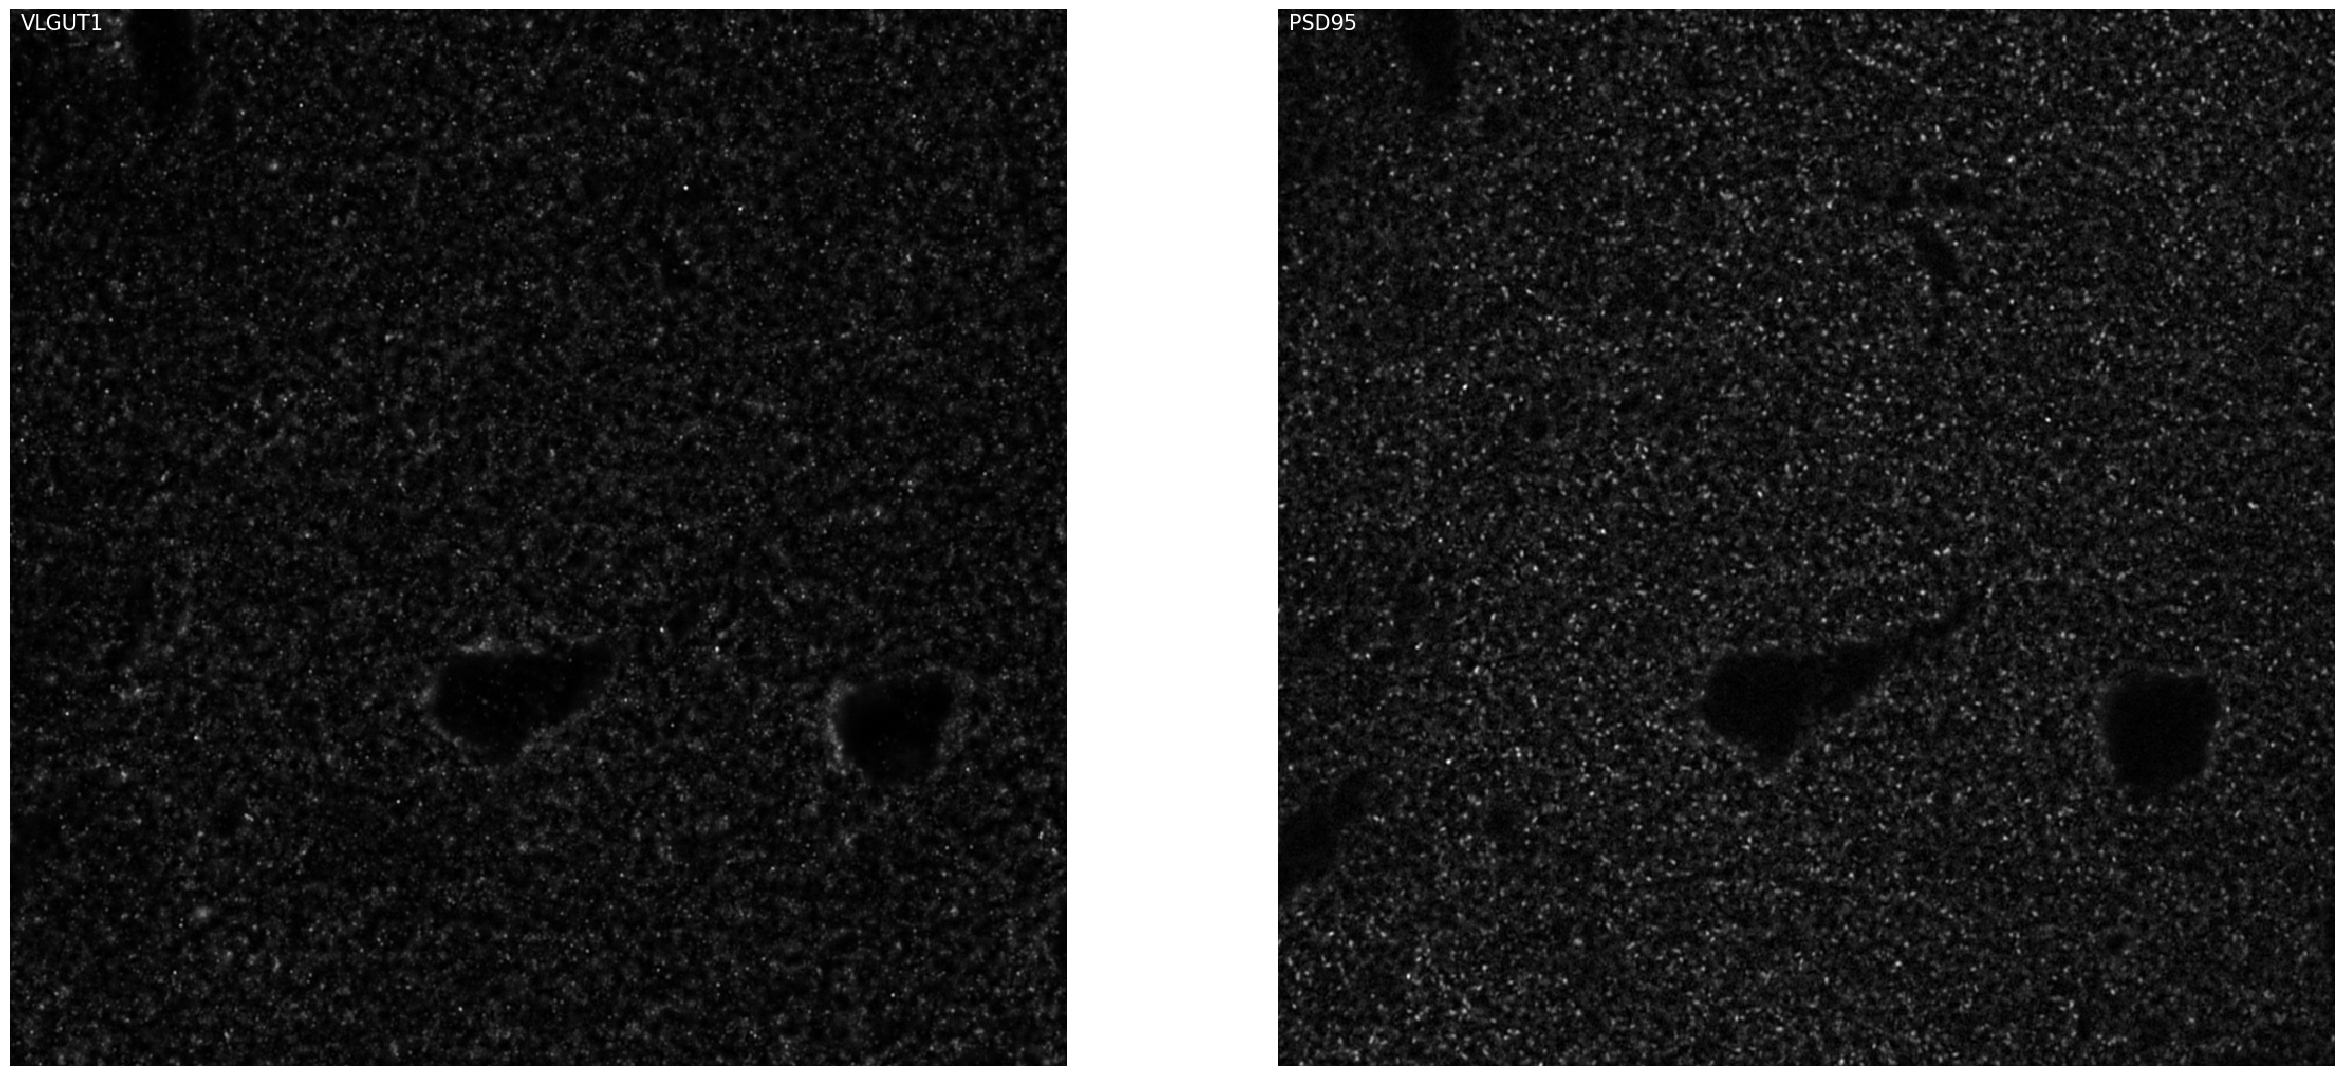

In [69]:
# now a preproccesing step, removal of background with rolling ball radius of 10x
background_vglut1 = rolling_ball(vglut1, radius = 10)
background_psd95 = rolling_ball(psd95, radius = 10)
vglut1_bs = vglut1 - background_vglut1
psd95_bs = psd95 - background_psd95

fig, axs = plt.subplots(1, 2, figsize = (30, 30))
microshow(vglut1_bs, ax=axs[0], label_text = 'VLGUT1')
microshow(psd95_bs, ax=axs[1], label_text = 'PSD95')

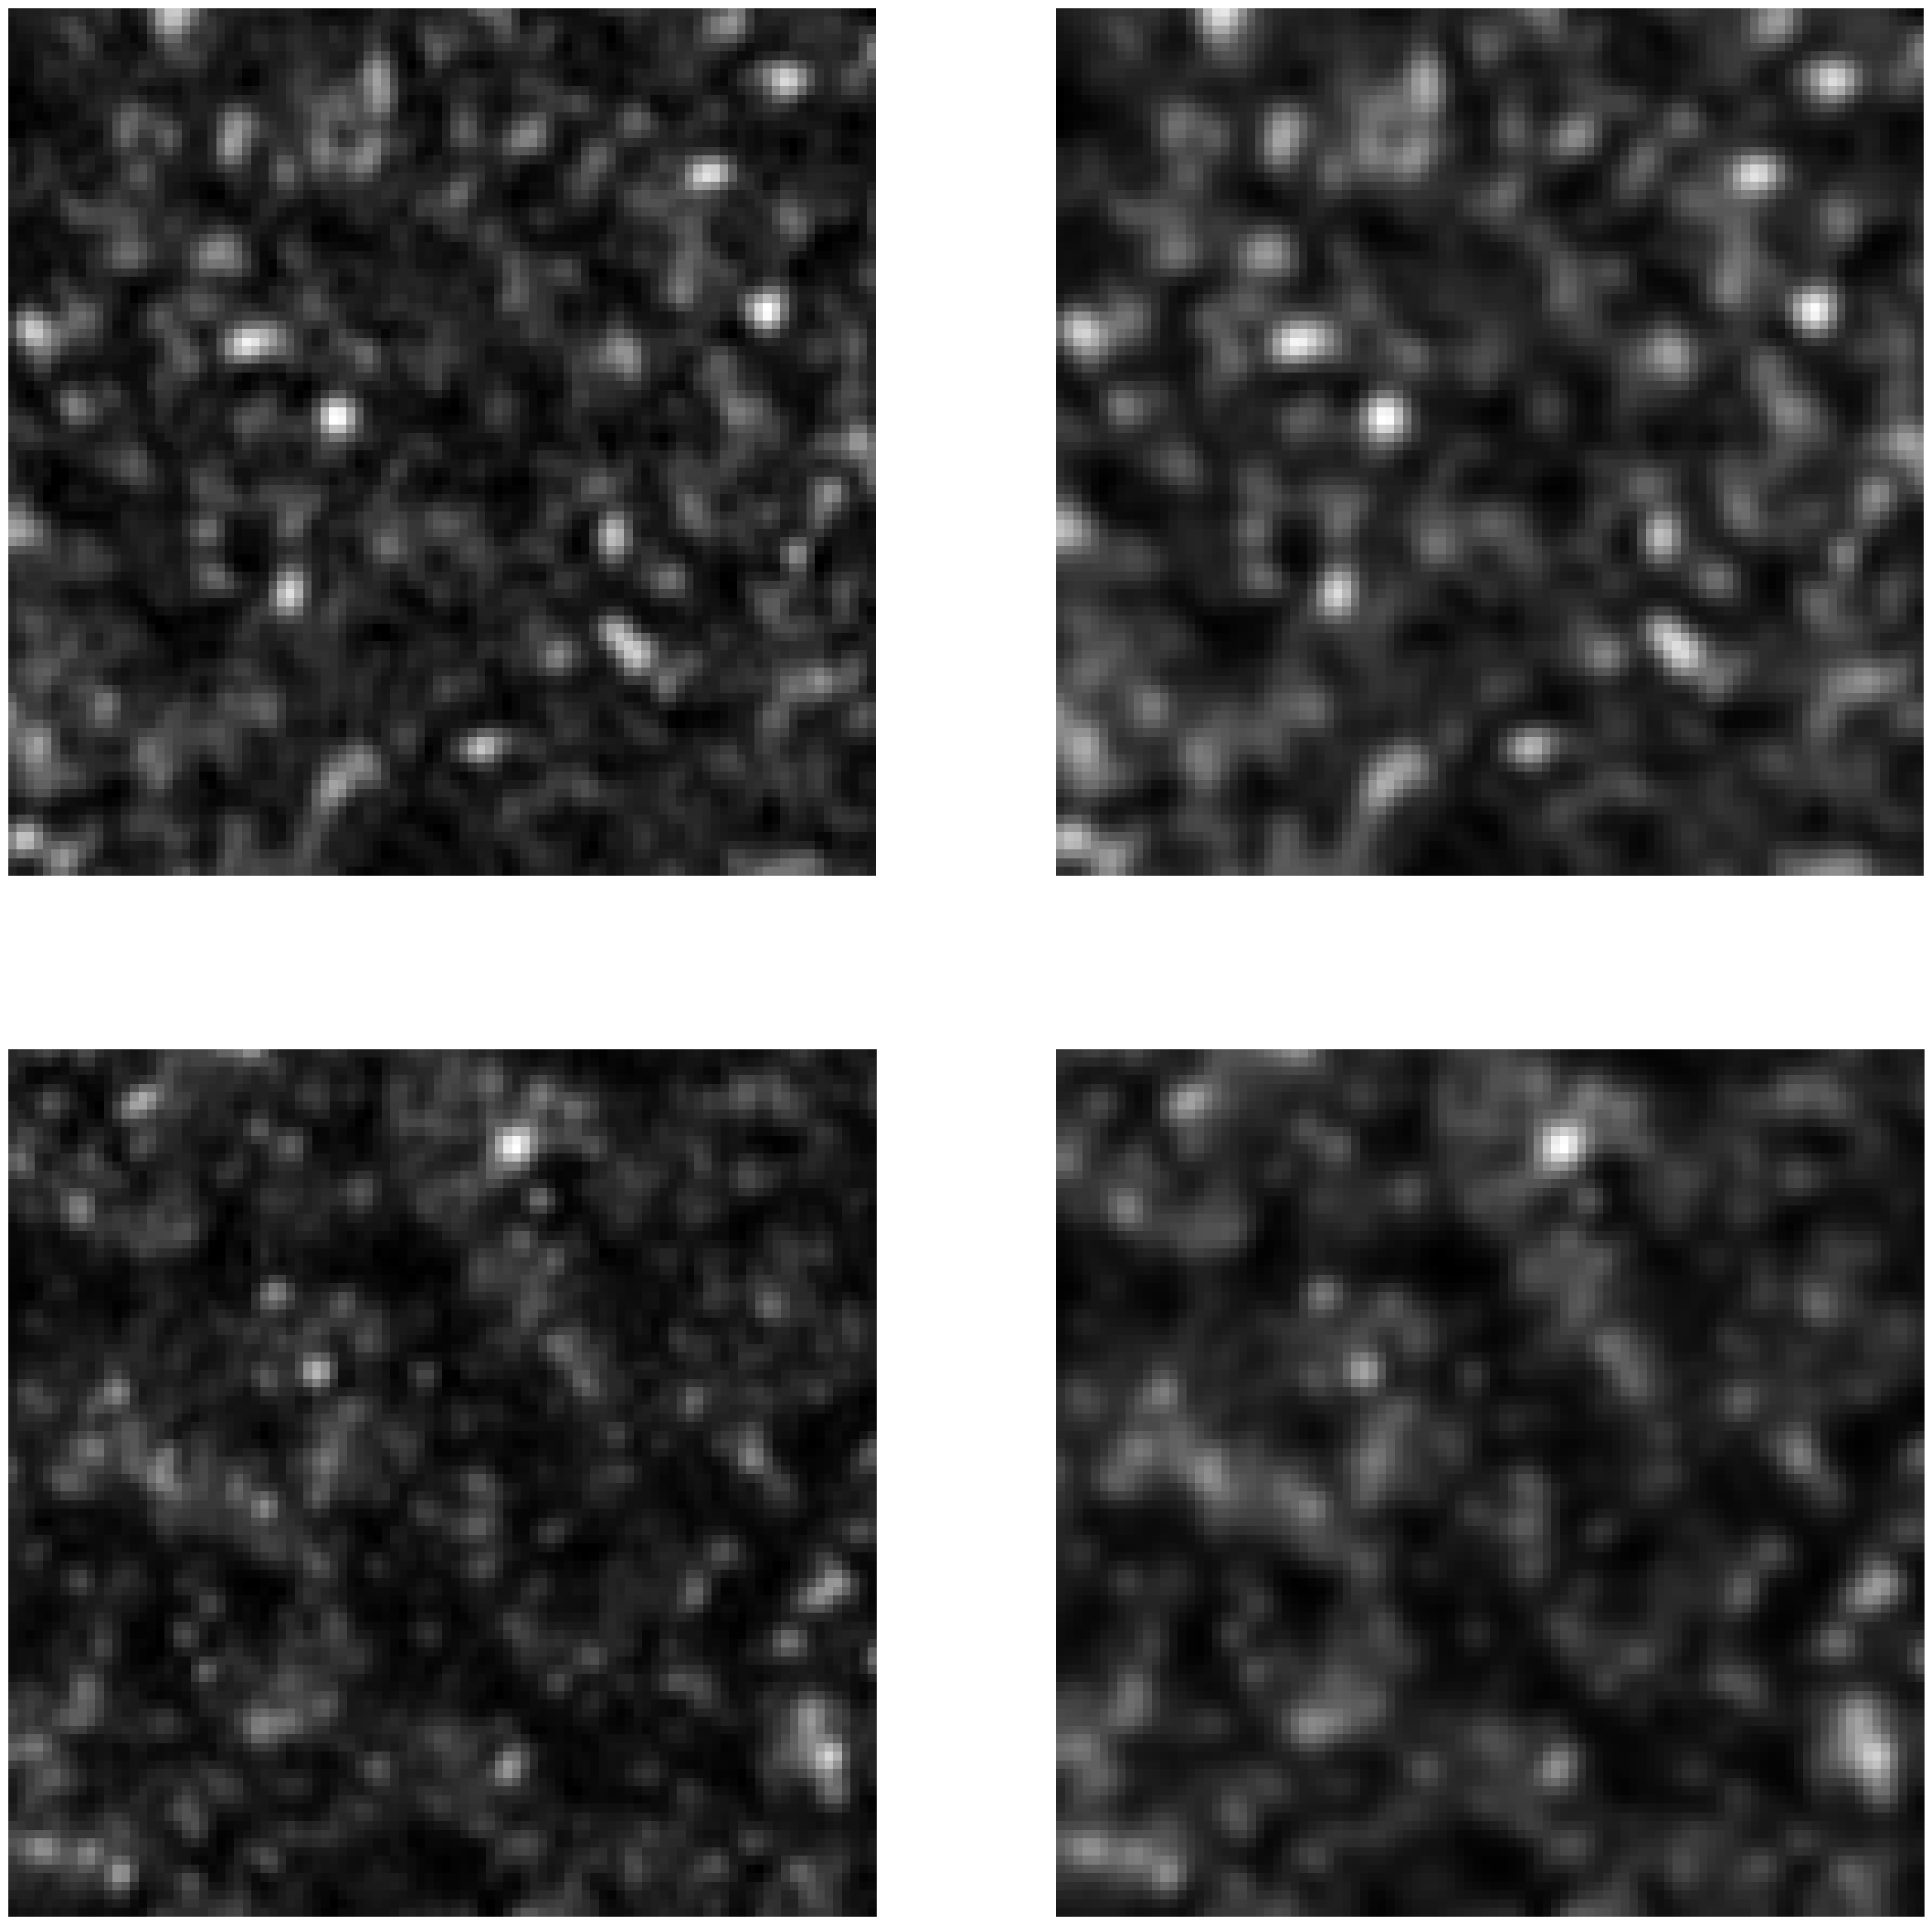

In [70]:
psd95_crop = psd95_bs[700:800, 500:600]
psd95_pre = gaussian(psd95_crop, sigma=1, preserve_range=True)

vglut1_crop = vglut1_bs[700:800, 500:600]
vglut1_pre = gaussian(vglut1_crop, sigma=1, preserve_range=True)

fig, axs = plt.subplots(2, 2, figsize = (30, 30))
microshow(psd95_crop, ax=axs[0,0])
microshow(psd95_pre, ax=axs[0,1])
microshow(vglut1_crop, ax=axs[1,0])
microshow(vglut1_pre, ax=axs[1,1])

In [71]:
psd95_coordinates = peak_local_max(psd95_pre, min_distance = 1, threshold_abs=600)
vglut1_coordinates = peak_local_max(vglut1_pre, min_distance = 1, threshold_abs=600)

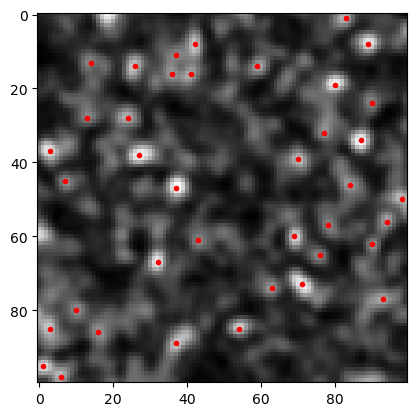

In [72]:
cle.imshow(psd95_pre, continue_drawing=True)
plt.plot(psd95_coordinates[:, 1], psd95_coordinates[:, 0], 'r.')

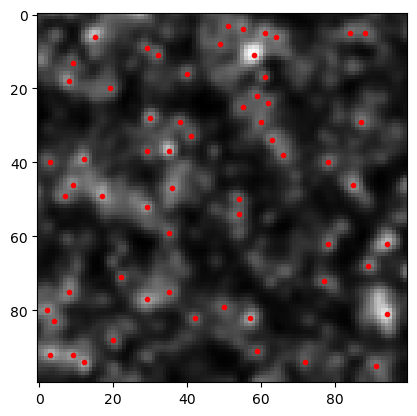

In [73]:
cle.imshow(vglut1_pre, continue_drawing=True)
plt.plot(vglut1_coordinates[:, 1], vglut1_coordinates[:, 0], 'r.')

In [74]:
# now we merge the coordinates to check how many spots are colocalized
all_spots = np.concatenate((vglut1_coordinates, psd95_coordinates), axis = 0)

In [75]:
# this retrieves the metadata and the extracts to pixel_to_um conversion

from lxml import etree # required library to load the metadata

czi = czifile.CziFile("D:/code/Image-analysis/test-images-VLGUT1-PSD95/OE_Exp1_IHC_Exp1_HA-GPR37L1_555-VGLUT1_647-PSD95_63X_airyscan_1.8zoom_CA1_SO.czi")
czi_xml_str = czi.metadata() # gets the metadata in a xml string format
czi_parsed = etree.fromstring(czi_xml_str) # parses the czi_xml_str file

# finds the strings 
size_x = czi_parsed.find(".//SizeX")
size_y = czi_parsed.find(".//SizeY")
scaling_x = czi_parsed.find(".//ScalingX")
scaling_y = czi_parsed.find(".//ScalingY")

# Extracting the required values to calculate the 
size_x_value = int(size_x.text)
size_y_value = int(size_y.text)
scaling_x_value = float(scaling_x.text)
scaling_y_value = float(scaling_y.text)

# calculater the pixel to micrometer (um)
# first checking whether the X and Y dimensions of the image are equal
if size_x_value == size_y_value and scaling_x_value == scaling_y_value:
    pixel_to_um = (size_x_value/scaling_x_value)*0.000000001
    
print(pixel_to_um, "pixels per 1 um")


13.65827631786121 pixels per 1 um


In [83]:
# This block of code calculates the unique colocalized VGLUT1-PSD95 count, meaning it only has unique pairs of colocalized spots.
# It checks of every VLGUT1 and PSD95 spot, whether there are any PSD95 (for VGLUT1) and VLGUT1 (for PSD95) spots in their vicinity with a specific maximum distance and counts it. 
# So it can have for one spot, multiple pairs.

from scipy.spatial.distance import cdist

# Count spots with a maximum distance of 0.5 um
max_distance = pixel_to_um * 0.5  # in pixels

# Calculate pairwise distances between spots in Channel 1 and Channel 2
distances_vglut1_to_psd95 = cdist(vglut1_coordinates, psd95_coordinates)
distances_psd95_to_vglut1 = cdist(psd95_coordinates, vglut1_coordinates)

# Find unique colocalized spots
colocalized_spots = set()

# Iterate over distances from vglut1_coordinates to psd95_coordinates
for i in range(len(vglut1_coordinates)):
    # Check if the current spot in Channel 1 has nearby spots in Channel 2
    colocalized_indices = [j for j, distance in enumerate(distances_vglut1_to_psd95[i, :]) if distance <= max_distance]
    for j in colocalized_indices:
        colocalized_spots.add((i, j))

# Iterate over distances from psd95_coordinates to vglut1_coordinates
for i in range(len(psd95_coordinates)):
    # Check if the current spot in Channel 2 has nearby spots in Channel 1
    colocalized_indices = [j for j, distance in enumerate(distances_psd95_to_vglut1[i, :]) if distance <= max_distance]
    for j in colocalized_indices:
        colocalized_spots.add((j, i))

# Get the count of unique colocalized spots
colocalized_spot_count = len(colocalized_spots)

print("Number of unique colocalized spots with maximum distance of 0.7 um:", colocalized_spot_count)
print("Number of VLGUT1 spots:", len(vglut1_coordinates))
print("Number of PSD95 spots:", len(psd95_coordinates))

Number of unique colocalized spots with maximum distance of 0.7 um: 41
Number of VLGUT1 spots: 61
Number of PSD95 spots: 39
